In [1]:
import pandas as pd

In [2]:
# find all the species with data in "results" folder

import os
filenames = os.listdir("results")

In [5]:
summary_files = [file for file in filenames if file.endswith("summary.csv")]
transfer_files = [file for file in filenames if file.endswith("transfers.csv")]

In [7]:
len(transfer_files), len(summary_files)

(595, 595)

In [11]:
all_res = []
for filename in summary_files:
    res = pd.read_csv("results/" + filename)
    res["species"] = filename.split("__")[0]
    all_res.append(res)

all_res = pd.concat(all_res)
all_res.drop(columns=["Unnamed: 0"], inplace=True)
all_res.reset_index(drop=True, inplace=True)

/var/folders/hg/9rp27v5d51d0948tcdf8mkk80000gq/T/ipykernel_12827/1070988562.py:7: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  all_res = pd.concat(all_res)


In [16]:
all_res.set_index(['genome1', 'genome2'], inplace=True)

In [13]:
# ugly workaround for now
import sys
sys.path.append('/Users/Device6/Documents/Research/bgoodlab/microbiome_codiv/comigration_metagenomics/')
from utils import snv_utils, metadata_utils, pairwise_utils
import config

pairwise_helper = pairwise_utils.PairwiseHelper(databatch=config.databatch)

In [14]:
drep_summary = pairwise_helper.hgt_summary[pairwise_helper.hgt_summary['species'].isin(all_res['species'].unique())]

In [17]:
def div_to_years(div, gen_per_day=1, mut_rate=4.08e-10):
    mut_per_year = mut_rate * 365 * gen_per_day
    return div / mut_per_year

drep_summary = drep_summary.set_index(['genome1', 'genome2'])
all_res['ani'] = drep_summary.loc[all_res.index, 'ani']
all_res['perc_id'] = drep_summary.loc[all_res.index, 'perc_id']
all_res['div_years'] = div_to_years(all_res['est_div'])

Text(0, 0.5, 'Percent identical genes')

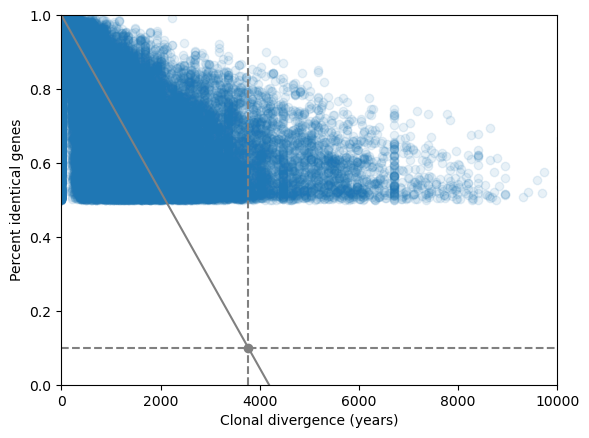

In [33]:
import numpy as np
import matplotlib.pyplot as plt

x = all_res['div_years']
y = all_res['perc_id']

perc_id_threshold = 0.4
x_fit = x[y >= perc_id_threshold]
y_fit = y[y >= perc_id_threshold]

plt.scatter(x_fit, y_fit, alpha=0.1)

# fit the slope of y= 1- b * x
from scipy.optimize import curve_fit
def func(y, b):
    return b * (1 - y)

popt, pcov = curve_fit(func, y_fit, x_fit)

year_at_10p = popt * 0.9

# xplot = np.linspace(0, 10000)
yplot = np.linspace(0, 1)
plt.plot(func(yplot, *popt), yplot, '-', color='grey')

plt.scatter(year_at_10p, 0.1, color='grey')
plt.axvline(x=year_at_10p, color='grey', linestyle='--')
plt.axhline(y=0.1, color='grey', linestyle='--')

plt.ylim([0, 1])
plt.xlim([0, 10000])

plt.xlabel('Clonal divergence (years)')
plt.ylabel('Percent identical genes')
# plt.title(species)

In [74]:
len(x_fit)

66304

/var/folders/hg/9rp27v5d51d0948tcdf8mkk80000gq/T/ipykernel_12827/3741145978.py:17: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  plt.plot(func(yplot, *popt), yplot, '-', color='grey', label='10% ~ {} years'.format(int(year_at_10p)))


[3767.20345917]


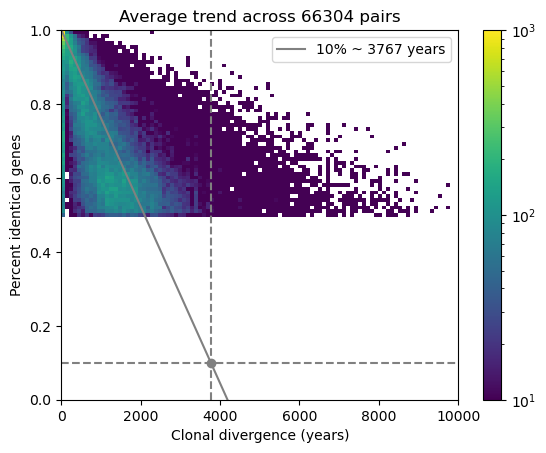

In [76]:
import seaborn as sns
from matplotlib.colors import LogNorm

# sns.jointplot(x=x_fit, y=y_fit, kind='hex', color='blue', marginal_kws=dict(bins=100, fill=True))
# log cbar scale
binx = np.linspace(0, 10000, 100)
biny = np.linspace(0, 1, 100)

sns.histplot(x=x_fit, y=y_fit, bins=(binx, biny), cbar=True, norm=LogNorm(vmin=10, vmax=1e3), vmin=None, vmax=None,
             cmap='viridis')
# sns.histplot(x=x_fit, y=y_fit, bins=(binx, biny), cbar=True, vmin=None, vmax=None)

plt.xlim(0, 10000)
plt.ylim(0, 1)

yplot = np.linspace(0, 1)
plt.plot(func(yplot, *popt), yplot, '-', color='grey', label='10% ~ {} years'.format(int(year_at_10p)))

print(year_at_10p)
plt.scatter(year_at_10p, 0.1, color='grey')
plt.axvline(x=year_at_10p, color='grey', linestyle='--')
plt.axhline(y=0.1, color='grey', linestyle='--')

plt.xlabel('Clonal divergence (years)')
plt.ylabel('Percent identical genes')
plt.title("Average trend across {} pairs".format(len(x_fit)))
plt.legend()
plt.savefig("perc_id_vs_div.pdf", dpi=300)